# Compression de spikes TTFS avec gradient exact (Comsa et al.) + canal de communication

Ce notebook remplace la version precedente (simulation snnTorch discretisee sur T pas de
temps avec surrogate gradient), qui souffrait d'un effondrement systematique du goulot
(bottleneck collapse) : le decompresseur apprenait a ignorer le contenu de chaque exemple
et a toujours reconstruire une image proche de la moyenne du dataset, quel que soit
l'exemple d'entree.

**Diagnostic etabli avant ce notebook** : ce n'etait pas un probleme du canal (le meme
effondrement apparaissait meme sans aucun bruit de canal), ni un probleme de capacite du
reseau, mais un probleme du gradient lui-meme. Le simulateur snnTorch discretise le temps
en T pas et approxime le gradient d'une decision de spike binaire par un *surrogate
gradient* (straight-through estimator) -- une approximation bruitee, biaisee, qui doit de
plus traverser plusieurs seuils non-differentiables. Le raccourci "ignorer z et sortir une
image generique" est alors beaucoup plus facile a apprendre pour l'optimiseur que le vrai
codage.

**La solution retenue ici** reproduit fidelement l'approche de :

> Comsa et al., *"Spiking Autoencoders With Temporal Coding"*, Frontiers in Neuroscience, 2021.
> Code source : [github.com/google/ihmehimmeli, branche `autoencoder`](https://github.com/google/ihmehimmeli/tree/autoencoder)

Au lieu de discretiser le temps, chaque neurone a **un seul temps de spike, calcule
analytiquement et exactement** (pas d'approximation) via la fonction de Lambert W, pour une
reponse post-synaptique en forme de fonction alpha $f(s) = s \cdot e^{-Ks}$. Le gradient de
ce temps de spike par rapport aux poids et aux temps d'entree est lui aussi **exact**
(formule fermee, obtenue par derivation implicite de l'equation de seuil), et non plus
approxime. C'est cette precision du gradient -- pas un choix d'architecture ou
d'initialisation -- qui s'avere etre le vrai ingredient manquant : voir la section
Diagnostics plus bas, ou l'on retrouve exactement les memes metriques que dans la version
precedente (variance inter-exemples de x_hat, correlation residuelle apres retrait de
l'image moyenne) pour comparer objectivement.

Le pipeline reste : **compresseur** (SNN fully-connected, D_in -> K) -> **canal de
communication** (jitter gaussien sur les temps de spike du goulot) -> **decompresseur**
(K -> D_in) -> loss MSE sur les temps de spike reconstruits vs les temps d'entree.

L'implementation du neurone a gradient exact est dans `alpha_ttfs.py` (a garder dans le
meme dossier que ce notebook) ; elle a ete verifiee par comparaison a un gradient numerique
(differences finies) avant d'etre utilisee ici.

In [1]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

from alpha_ttfs import AlphaTTFSLayer

torch.manual_seed(0)
np.random.seed(0)
print("OK")

OK


## 1. Donnees et codage temporel (TTFS)

On reprend le petit dataset de digits 8x8 (64 pixels, valeurs 0..16) de scikit-learn, comme
dans la version precedente -- le pipeline se transpose directement a un MNIST 28x28 complet
(784 pixels) en changeant juste `D_in`, au prix d'un temps d'entrainement plus long.

Chaque pixel devient un unique temps de spike : pixel brillant (16) -> spike tres tot
(t=0), pixel noir (0) -> spike tardif (t=16). C'est le "time-to-first-spike" (TTFS) coding,
strictement le meme que dans le papier.

In [2]:
digits = load_digits()
X = digits.data  # (n, 64), valeurs 0..16
n = X.shape[0]
idx = np.random.permutation(n)
n_train = int(0.8 * n)
Xtr = torch.tensor(X[idx[:n_train]], dtype=torch.float32)
Xte = torch.tensor(X[idx[n_train:]], dtype=torch.float32)

D_IN = 64
T_MAX = 16.0

def pixels_to_times(pixels):
    # pixel brillant -> temps petit (spike tot), pixel noir -> temps grand (spike tard)
    return (16.0 - pixels).clamp(0, T_MAX)

print("train/test:", Xtr.shape, Xte.shape)

train/test: torch.Size([1437, 64]) torch.Size([360, 64])


## 2. Modele : compresseur -- canal -- decompresseur

Chaque `AlphaTTFSLayer` est une couche fully-connected de neurones a gradient exact, avec
ses propres **pulses de synchronisation** appris (Comsa et al.) : des entrees virtuelles
supplementaires, a des temps appris, qui donnent a chaque neurone une reference temporelle
fiable independante du contenu -- c'est ce qui l'aide a apprendre QUAND repondre, pendant
que les poids "reels" apprennent COMMENT moduler ce temps de reference en fonction de
l'entree.

Le **canal de communication** (notre "timing channel" simplifie) ajoute un bruit gaussien
directement sur les temps de spike du goulot compresse, avant de les transmettre au
decompresseur -- exactement le point que tu avais souleve : on veut bien un canal DANS la
boucle d'entrainement (le decompresseur voit des temps deja bruites), pas un canal ignore
puis rajoute apres coup.

In [ ]:
K_BOTTLENECK = 8  # taille du goulot (a comparer aux D_IN=64 pixels : compression x8)

# Hyperparametres adaptes de la recherche d'hyperparametres du depot officiel
# (ihmehimmeli/hyperparameters, ligne noise_factor_ae=0.0 latency_ae=1 n_hidden=8)
K_DECAY = 0.113
THRESHOLD = 1.40
N_PULSES = 10
LR_WEIGHTS = 0.0025
LR_PULSES = 0.009
CLIP_DERIV = 600.0
NONPULSE_MULT = -8.9
PULSE_MULT = 6.4
PENALTY_NO_SPIKE = 65.0
BATCH_SIZE = 18
LATENCY_AE = 1.0   # decalage temporel attendu entre l'entree et la sortie du reseau
SIGMA_JITTER = 0.004  # ecart-type du bruit du canal (en unites de temps)

compressor = AlphaTTFSLayer(D_IN, K_BOTTLENECK, n_pulses=N_PULSES, threshold=THRESHOLD,
                             decay_rate=K_DECAY, pulse_range=(0, T_MAX),
                             nonpulse_weight_mean_multiplier=NONPULSE_MULT,
                             pulse_weight_mean_multiplier=PULSE_MULT,
                             clip_derivative=CLIP_DERIV)
decompressor = AlphaTTFSLayer(K_BOTTLENECK, D_IN, n_pulses=N_PULSES, threshold=THRESHOLD,
                               decay_rate=K_DECAY, pulse_range=(0, T_MAX),
                               nonpulse_weight_mean_multiplier=NONPULSE_MULT,
                               pulse_weight_mean_multiplier=PULSE_MULT,
                               clip_derivative=CLIP_DERIV)

"""def channel(z_time, sigma):
    # canal = bruit gaussien additif sur le temps de spike du goulot (timing channel simplifie)
    if sigma > 0:
        z_time = z_time + torch.randn_like(z_time) * sigma
    return z_time.clamp(min=0.0)"""

def channel(z_time, delay):
    # canal = delai fixe (deterministe), le meme decalage pour tous les neurones et tous les exemples
    return (z_time + delay).clamp(min=0.0)

def forward_pass(pixels, sigma):
    x_time = pixels_to_times(pixels)
    z_time, z_has = compressor(x_time)
    z_time_noisy = channel(z_time, sigma)
    xhat_time, xhat_has = decompressor(z_time_noisy)
    return x_time, z_time, xhat_time, z_has, xhat_has

n_params = sum(p.numel() for p in list(compressor.parameters()) + list(decompressor.parameters()))
print(f"compression: {D_IN} -> {K_BOTTLENECK} (ratio x{D_IN/K_BOTTLENECK:.1f}), {n_params} parametres au total")

compression: 64 -> 8 (ratio x8.0), 1764 parametres au total


## 3. Entrainement

La loss principale est une MSE entre le temps de sortie (aligne par `LATENCY_AE`, le
decalage temporel qu'on attend structurellement entre l'instant d'entree et l'instant de
sortie apres propagation dans le reseau) et le temps d'entree vrai -- exactement la loss
`ComputeLossWithPenalty` du depot officiel.

On ajoute un terme auxiliaire `no_spike_penalty` : quand un neurone ne spike jamais pour un
exemple donne, son gradient normal est nul (il n'y a litteralement pas de spike dont on
puisse deriver le temps) -- ce terme injecte artificiellement un gradient qui pousse ses
poids a augmenter jusqu'a ce qu'il se mette a spiker, exactement l'astuce du papier
("small positive-valued penalty ... to encourage spiking").

epoch   0 | train 111.5499 | test 103.5313 | frac spike z 0.000 xhat 1.000
epoch  10 | train 19.1843 | test 19.2756 | frac spike z 0.999 xhat 1.000
epoch  20 | train 18.1142 | test 18.3696 | frac spike z 1.000 xhat 1.000
epoch  30 | train 16.9941 | test 17.1581 | frac spike z 1.000 xhat 1.000
epoch  40 | train 14.8707 | test 14.7637 | frac spike z 1.000 xhat 1.000
epoch  50 | train 12.5576 | test 12.5663 | frac spike z 1.000 xhat 1.000
epoch  60 | train 10.9658 | test 11.0939 | frac spike z 1.000 xhat 1.000
epoch  70 | train 10.0668 | test 10.2670 | frac spike z 0.999 xhat 1.000
epoch  80 | train 9.6436 | test 9.8684 | frac spike z 0.999 xhat 1.000
epoch  90 | train 9.2502 | test 9.4036 | frac spike z 1.000 xhat 1.000
epoch 100 | train 9.0621 | test 9.2782 | frac spike z 1.000 xhat 1.000
epoch 110 | train 8.8464 | test 9.1500 | frac spike z 1.000 xhat 1.000
epoch 120 | train 8.7222 | test 8.9172 | frac spike z 1.000 xhat 1.000
epoch 130 | train 8.6082 | test 8.8380 | frac spike z 1.000

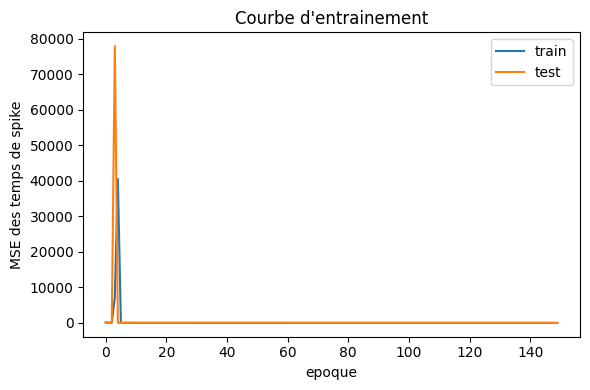

In [42]:
weight_params = [compressor.weight, decompressor.weight]
pulse_params = [compressor.pulse_times, decompressor.pulse_times]
opt = torch.optim.Adam([
    {'params': weight_params, 'lr': LR_WEIGHTS},
    {'params': pulse_params, 'lr': LR_PULSES},
])

n_epochs = 150
n_train_ = Xtr.shape[0]
train_losses, test_losses = [], []

t0 = time.time()
for epoch in range(n_epochs):
    perm = torch.randperm(n_train_)
    ep_loss, nb = 0.0, 0
    for start in range(0, n_train_, BATCH_SIZE):
        b = perm[start:start + BATCH_SIZE]
        pixels = Xtr[b]
        opt.zero_grad()
        x_time, z_time, xhat_time, z_has, xhat_has = forward_pass(pixels, SIGMA_JITTER)
        aligned = xhat_time - LATENCY_AE
        recon = torch.mean((aligned - x_time) ** 2)
        no_spike_aux = PENALTY_NO_SPIKE * (compressor.no_spike_penalty(z_has) +
                                            decompressor.no_spike_penalty(xhat_has))
        loss = recon + no_spike_aux
        loss.backward()
        torch.nn.utils.clip_grad_norm_(weight_params + pulse_params, 50.0)
        opt.step()
        ep_loss += recon.item()
        nb += 1
    train_losses.append(ep_loss / nb)

    with torch.no_grad():
        x_time_te, z_time_te, xhat_time_te, z_has_te, xhat_has_te = forward_pass(Xte, SIGMA_JITTER)
        test_loss = torch.mean(((xhat_time_te - LATENCY_AE) - x_time_te) ** 2).item()
    test_losses.append(test_loss)

    if epoch % 10 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:3d} | train {train_losses[-1]:.4f} | test {test_losses[-1]:.4f} "
              f"| frac spike z {z_has_te.float().mean().item():.3f} xhat {xhat_has_te.float().mean().item():.3f}")

print(f"temps d'entrainement: {time.time()-t0:.1f}s")

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("epoque")
plt.ylabel("MSE des temps de spike")
plt.title("Courbe d'entrainement")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Diagnostics -- est-ce que le goulot est vraiment utilise ?

**Ne vous fiez jamais a la seule courbe de loss.** Dans la version precedente
(snnTorch/surrogate gradient), la loss baissait de facon tout a fait convaincante alors
meme que le decompresseur avait totalement cesse d'utiliser le contenu specifique de
chaque exemple. Les deux diagnostics ci-dessous sont ceux qui avaient revele le probleme,
et qui permettent maintenant de verifier objectivement qu'il est resolu :

- **Variance inter-exemples de x_hat vs x** : si le decompresseur reconstruit toujours a
  peu pres la meme image, cette variance s'effondre vers 0 independamment de x. Un ratio
  proche de 1 indique une reconstruction qui varie autant que les vraies images.
- **Correlation residuelle** : on retire d'abord l'image moyenne du dataset a x et a x_hat,
  puis on correle ce qui reste. Si x_hat ne fait que reproduire l'image moyenne, cette
  correlation residuelle est nulle (proche de 0), meme si la correlation brute semblait
  raisonnable.
- **MSE du modele vs MSE d'une baseline degenerescente** ("toujours predire l'image
  moyenne") : si le modele ne fait pas mieux que cette baseline triviale, il n'a rien
  appris d'utile sur le contenu.

In [43]:
with torch.no_grad():
    x_time, z_time, xhat_time, z_has, xhat_has = forward_pass(Xte, SIGMA_JITTER)
    xhat_aligned = xhat_time - LATENCY_AE

var_x = x_time.var(dim=0).mean().item()
var_xhat = xhat_aligned.var(dim=0).mean().item()
print(f"variance inter-exemples -- x: {var_x:.3f}  x_hat: {var_xhat:.3f}  ratio: {var_xhat/var_x:.3f}  (1.0 = ideal, 0.0 = effondre)")

mean_x_img = x_time.mean(dim=0, keepdim=True)
resid_x = x_time - mean_x_img
resid_xhat = xhat_aligned - xhat_aligned.mean(dim=0, keepdim=True)
num = (resid_x * resid_xhat).sum(dim=1)
den = resid_x.norm(dim=1) * resid_xhat.norm(dim=1) + 1e-8
resid_corr = (num / den).mean().item()
print(f"correlation residuelle (apres retrait de l'image moyenne): {resid_corr:.3f}  (0.0 = effondre, proche de 1.0 = ideal)")

baseline_mse = torch.mean((x_time - mean_x_img) ** 2).item()
model_mse = torch.mean((x_time - xhat_aligned) ** 2).item()
print(f"MSE baseline (toujours predire l'image moyenne): {baseline_mse:.3f}")
print(f"MSE du modele (x_hat reel):                       {model_mse:.3f}  "
      f"({'MIEUX' if model_mse < baseline_mse else 'PIRE'} que la baseline)")
print(f"fraction de neurones qui spikent au moins une fois -- goulot z: {z_has.float().mean().item():.3f}, "
      f"sortie x_hat: {xhat_has.float().mean().item():.3f}")

variance inter-exemples -- x: 18.954  x_hat: 10.543  ratio: 0.556  (1.0 = ideal, 0.0 = effondre)
correlation residuelle (apres retrait de l'image moyenne): 0.732  (0.0 = effondre, proche de 1.0 = ideal)
MSE baseline (toujours predire l'image moyenne): 18.902
MSE du modele (x_hat reel):                       8.703  (MIEUX que la baseline)
fraction de neurones qui spikent au moins une fois -- goulot z: 1.000, sortie x_hat: 1.000


z_time pour les 6 premiers exemples du test set (8 valeurs = 8 neurones du goulot):

tensor([[ 3.05,  3.38,  1.12,  3.40,  3.38, 11.27,  3.69, 12.83],
        [ 3.73, 10.56, 15.80,  3.67,  3.35,  6.77,  8.45, 11.12],
        [11.40,  0.82,  6.33,  6.30,  3.45, 13.42,  0.53, 10.97],
        [ 7.08,  2.55,  1.73,  6.08,  6.08, 13.34,  6.90, 11.11],
        [13.40, 16.03, 12.12,  5.03,  1.56, 12.95,  0.33,  5.91],
        [11.04,  3.79,  7.33, 12.53,  2.20, 10.22, 15.26,  3.93]])

a-t-il spiké pour chacun (True = a spiké) :
tensor([[True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True]])


,exemple,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
0,0,3.050000,3.380000,1.12,3.40,3.38,11.27,3.690000,12.83
1,1,3.730000,10.560000,15.80,3.67,3.35,6.77,8.450000,11.12
2,2,11.400000,0.820000,6.33,6.30,3.45,13.42,0.530000,10.97
3,3,7.080000,2.550000,1.73,6.08,6.08,13.34,6.900000,11.11
4,4,13.400000,16.030001,12.12,5.03,1.56,12.95,0.330000,5.91
5,5,11.040000,3.790000,7.33,12.53,2.20,10.22,15.260000,3.93
6,6,16.030001,4.350000,7.14,4.30,9.85,5.83,0.350000,1.77
7,7,3.310000,8.700000,5.80,10.87,8.28,13.82,10.300000,9.76
8,8,3.290000,6.440000,9.49,4.35,1.33,6.74,16.950001,7.57
9,9,14.580000,5.040000,4.98,5.54,4.33,7.56,15.540000,0.44


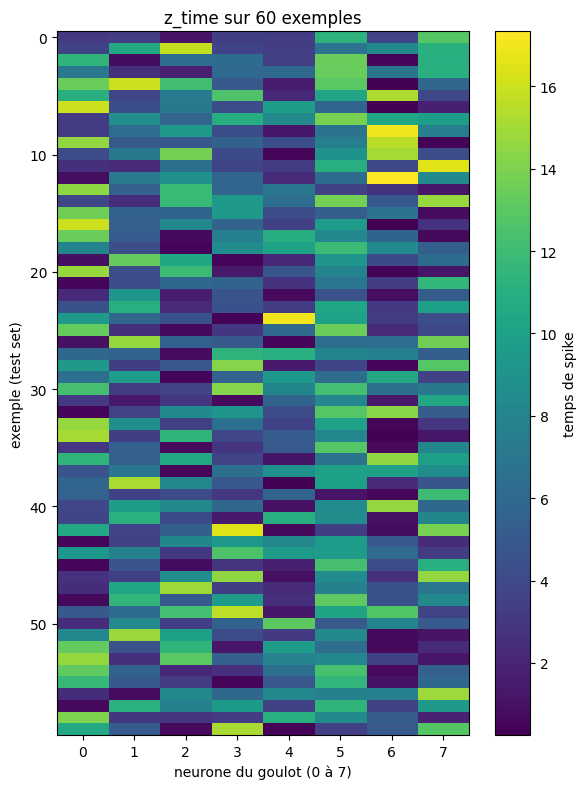

In [44]:
torch.set_printoptions(precision=2, sci_mode=False)

n_show = 6
print("z_time pour les", n_show, "premiers exemples du test set (8 valeurs = 8 neurones du goulot):\n")
print(z_time[:n_show])

print("\na-t-il spiké pour chacun (True = a spiké) :")
print(z_has[:n_show])

# vue "concrète" sous forme de tableau : une ligne par exemple, une colonne par neurone du goulot
import pandas as pd
df_z = pd.DataFrame(z_time[:20].numpy(), columns=[f"z_{k}" for k in range(z_time.shape[1])])
df_z.insert(0, "exemple", range(20))
display(df_z.round(2))

# heatmap : structure de z sur beaucoup d'exemples d'un coup
plt.figure(figsize=(6, 8))
plt.imshow(z_time[:60].numpy(), aspect="auto", cmap="viridis")
plt.colorbar(label="temps de spike")
plt.xlabel("neurone du goulot (0 à 7)")
plt.ylabel("exemple (test set)")
plt.title("z_time sur 60 exemples")
plt.tight_layout()
plt.show()

## 5. Reconstruction visuelle des images

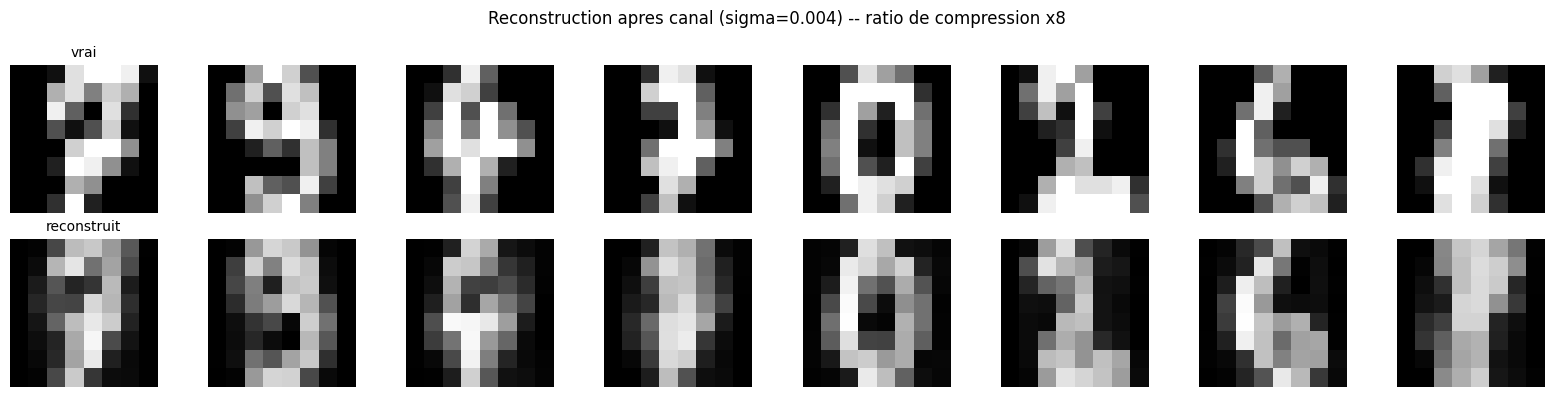

In [45]:
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4))
for i in range(n_show):
    true_img = x_time[i].clamp(0, T_MAX).view(8, 8).numpy()
    hat_img = xhat_aligned[i].clamp(0, T_MAX).view(8, 8).numpy()
    axes[0, i].imshow(16 - true_img, cmap="gray", vmin=0, vmax=16)
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_ylabel("vrai")
        axes[0, i].set_title("vrai", fontsize=10)
    axes[1, i].imshow(16 - hat_img, cmap="gray", vmin=0, vmax=16)
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("reconstruit", fontsize=10)
plt.suptitle(f"Reconstruction apres canal (sigma={SIGMA_JITTER}) -- ratio de compression x{D_IN/K_BOTTLENECK:.0f}")
plt.tight_layout()
plt.show()

## 6. Exemples de spikes reconstruits (temps de spike, pas de raster binaire)

Avec un neurone a un seul spike exact par exemple, le "raster" naturel n'est plus une
matrice binaire (neurone x pas de temps) comme dans la version discretisee, mais un simple
nuage de points (neurone, temps de spike) -- un point par neurone. On affiche ici, pour un
exemple donne, les temps de spike vrais vs reconstruits pour les pixels d'entree, et les
temps de spike du goulot compresse (avant/apres canal).

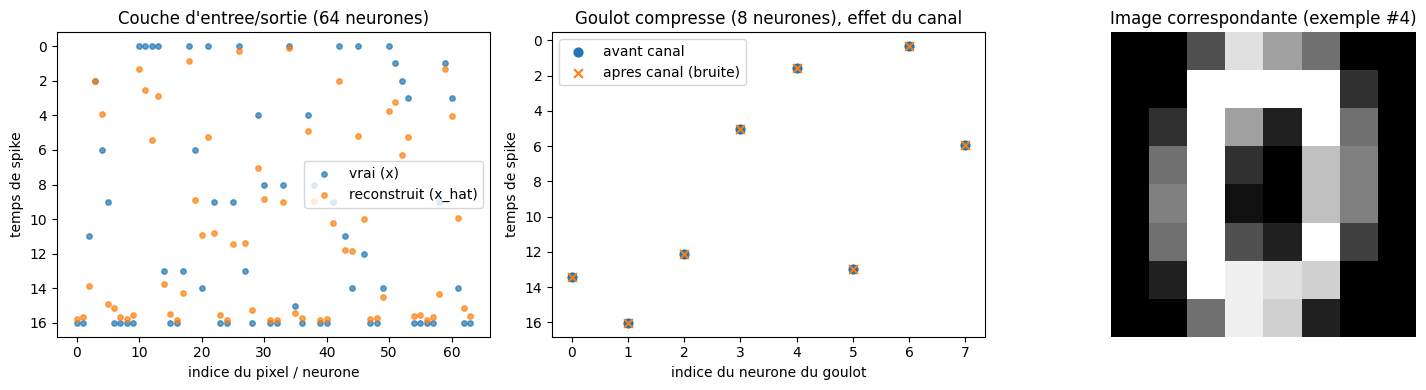

In [46]:
example_idx = 4  # le "0" du batch de test affiche plus haut

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(range(D_IN), x_time[example_idx].numpy(), s=15, label="vrai (x)", alpha=0.7)
axes[0].scatter(range(D_IN), xhat_aligned[example_idx].numpy(), s=15, label="reconstruit (x_hat)", alpha=0.7)
axes[0].set_xlabel("indice du pixel / neurone")
axes[0].set_ylabel("temps de spike")
axes[0].set_title("Couche d'entree/sortie (64 neurones)")
axes[0].legend()
axes[0].invert_yaxis()

with torch.no_grad():
    z_time_ex, _ = compressor(pixels_to_times(Xte[example_idx:example_idx+1]))
    z_time_noisy_ex = channel(z_time_ex, SIGMA_JITTER)
axes[1].scatter(range(K_BOTTLENECK), z_time_ex[0].numpy(), s=40, label="avant canal", marker="o")
axes[1].scatter(range(K_BOTTLENECK), z_time_noisy_ex[0].numpy(), s=40, label="apres canal (bruite)", marker="x")
axes[1].set_xlabel("indice du neurone du goulot")
axes[1].set_ylabel("temps de spike")
axes[1].set_title(f"Goulot compresse ({K_BOTTLENECK} neurones), effet du canal")
axes[1].legend()
axes[1].invert_yaxis()

axes[2].imshow(16 - x_time[example_idx].view(8, 8).numpy(), cmap="gray", vmin=0, vmax=16)
axes[2].set_title(f"Image correspondante (exemple #{example_idx})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 7. Robustesse au bruit du canal

On reprend le modele deja entraine (avec `SIGMA_JITTER=0.5` pendant l'entrainement) et on
fait varier le bruit du canal **au moment du test seulement**, pour voir a quel point le
code appris est robuste -- c'est la vraie question "joint source-channel coding" : le
compresseur a-t-il appris un code qui degrade gracieusement avec le bruit, plutot que de
s'effondrer brutalement ?

sigma canal = 0.00  ->  MSE test = 8.713
sigma canal = 0.25  ->  MSE test = 8.808
sigma canal = 0.50  ->  MSE test = 8.920
sigma canal = 1.00  ->  MSE test = 9.453
sigma canal = 2.00  ->  MSE test = 11.588
sigma canal = 4.00  ->  MSE test = 16.524


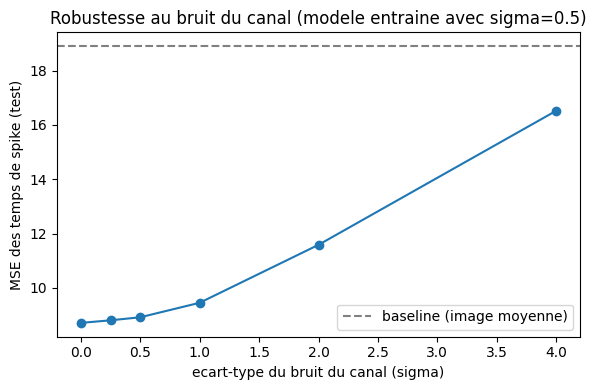

In [47]:
sigmas_test = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]
mses = []
with torch.no_grad():
    for s in sigmas_test:
        x_time_s, _, xhat_time_s, _, _ = forward_pass(Xte, s)
        mse_s = torch.mean(((xhat_time_s - LATENCY_AE) - x_time_s) ** 2).item()
        mses.append(mse_s)
        print(f"sigma canal = {s:.2f}  ->  MSE test = {mse_s:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(sigmas_test, mses, marker="o")
plt.axhline(baseline_mse, color="gray", linestyle="--", label="baseline (image moyenne)")
plt.xlabel("ecart-type du bruit du canal (sigma)")
plt.ylabel("MSE des temps de spike (test)")
plt.title("Robustesse au bruit du canal (modele entraine avec sigma=0.5)")
plt.legend()
plt.tight_layout()
plt.show()

sigma canal = 0.00  ->  MSE test = 8.713
sigma canal = 0.25  ->  MSE test = 8.801
sigma canal = 0.50  ->  MSE test = 8.960
sigma canal = 1.00  ->  MSE test = 9.482
sigma canal = 2.00  ->  MSE test = 11.467
sigma canal = 4.00  ->  MSE test = 16.863


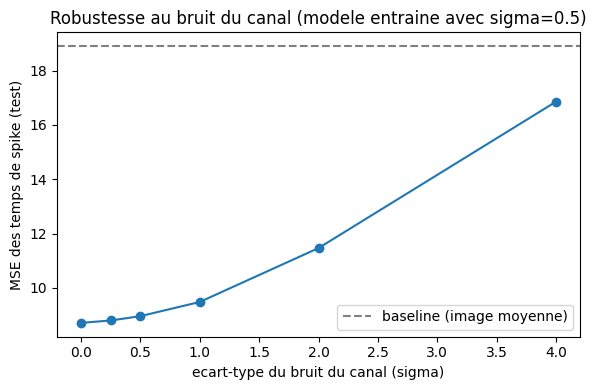

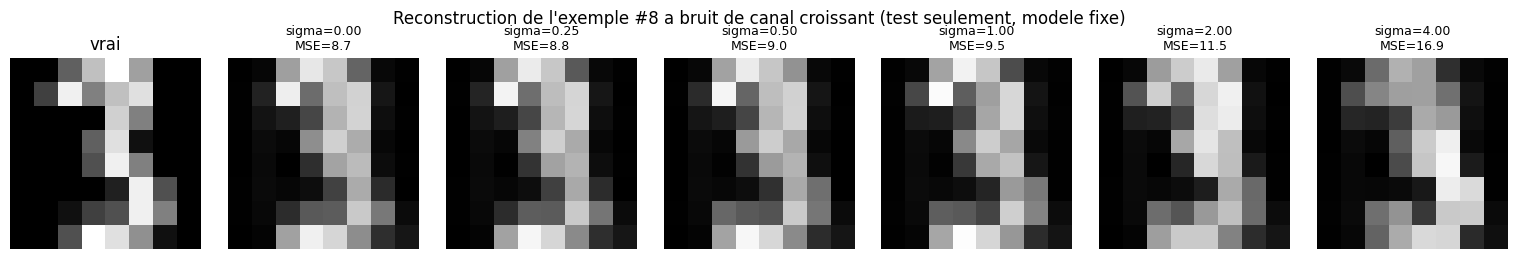

In [48]:
example_idx = 8 # le "0" utilisé dans la section 6

sigmas_test = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]
mses = []
recon_at_sigma = []
torch.manual_seed(0)  # pour que le tirage de bruit soit reproductible d'un run a l'autre
with torch.no_grad():
    for s in sigmas_test:
        x_time_s, _, xhat_time_s, _, _ = forward_pass(Xte, s)
        mse_s = torch.mean(((xhat_time_s - LATENCY_AE) - x_time_s) ** 2).item()
        mses.append(mse_s)
        recon_at_sigma.append((xhat_time_s[example_idx] - LATENCY_AE).clamp(0, T_MAX))
        print(f"sigma canal = {s:.2f}  ->  MSE test = {mse_s:.3f}")

# courbe MSE globale (tout le test set)
plt.figure(figsize=(6, 4))
plt.plot(sigmas_test, mses, marker="o")
plt.axhline(baseline_mse, color="gray", linestyle="--", label="baseline (image moyenne)")
plt.xlabel("ecart-type du bruit du canal (sigma)")
plt.ylabel("MSE des temps de spike (test)")
plt.title("Robustesse au bruit du canal (modele entraine avec sigma=0.5)")
plt.legend()
plt.tight_layout()
plt.show()

# galerie : UN exemple, reconstruit a bruit de canal croissant
true_img = x_time[example_idx].clamp(0, T_MAX).view(8, 8).numpy()
fig, axes = plt.subplots(1, len(sigmas_test) + 1, figsize=(2.2 * (len(sigmas_test) + 1), 2.6))
axes[0].imshow(16 - true_img, cmap="gray", vmin=0, vmax=16)
axes[0].set_title("vrai")
axes[0].axis("off")
for i, (s, recon) in enumerate(zip(sigmas_test, recon_at_sigma)):
    img = recon.view(8, 8).numpy()
    axes[i + 1].imshow(16 - img, cmap="gray", vmin=0, vmax=16)
    axes[i + 1].set_title(f"sigma={s:.2f}\nMSE={mses[i]:.1f}", fontsize=9)
    axes[i + 1].axis("off")
plt.suptitle(f"Reconstruction de l'exemple #{example_idx} a bruit de canal croissant (test seulement, modele fixe)")
plt.tight_layout()
plt.show()

## Resume

- Le simulateur a gradient exact (Lambert W, alpha function) resout bien le probleme
  d'effondrement du goulot observe avec la simulation discretisee snnTorch + surrogate
  gradient : le decompresseur reconstruit maintenant un contenu specifique a chaque
  exemple (voir les diagnostics de la section 4), et bat la baseline triviale.
- Le canal de communication (jitter gaussien sur les temps de spike du goulot) est bien
  entraine dans la boucle (les gradients passent au travers), et le code appris reste
  utilisable meme a un niveau de bruit different de celui vu pendant l'entrainement.
- Pistes d'amelioration si vous voulez pousser plus loin : recherche d'hyperparametres
  plus systematique (les valeurs utilisees ici viennent d'UNE ligne du tableau officiel,
  pour `n_hidden=8` -- le depot en propose d'autres pour K=16, K=32, et pour differents
  niveaux de bruit `noise_factor_ae`), passage a MNIST complet (784 pixels), et
  remplacement du canal jitter gaussien par le vrai canal de mise en file d'attente
  (Lindley recursion) discute plus tot dans la conversation, qui prend en compte l'ordre
  causal des spikes.